In [1]:
import os, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

# Пути на Drive
SPLIT_PATH   = "/content/drive/MyDrive/diploma/data/processed/dataset_split.parquet"
EMBED_DIR    = "/content/drive/MyDrive/diploma/data/embeddings"
MODELS_DIR   = "/content/drive/MyDrive/diploma/models/fasttext"
RESULTS_DIR  = "/content/drive/MyDrive/diploma/results"
FIGURES_DIR  = "/content/drive/MyDrive/diploma/figures"
FT_MODEL_PATH = "/content/drive/MyDrive/diploma/models/fasttext_geowac.bin"

for d in [EMBED_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

# Загружаем зафиксированный split
df = pd.read_parquet(SPLIT_PATH)
X_train = df.loc[df["split"] == "train", "text"].tolist()
X_val   = df.loc[df["split"] == "val",   "text"].tolist()
X_test  = df.loc[df["split"] == "test",  "text"].tolist()
y_train = df.loc[df["split"] == "train", "label"].values
y_val   = df.loc[df["split"] == "val",   "label"].values
y_test  = df.loc[df["split"] == "test",  "label"].values

print(f"train: {len(X_train):,}  val: {len(X_val):,}  test: {len(X_test):,}")

# --- хелперы для метрик (те же, что в baseline) ---

def measure_train_time(clf, X, y):
    t0 = time.perf_counter()
    clf.fit(X, y)
    return clf, time.perf_counter() - t0

def evaluate_classifier(clf, X_val, y_val, X_test, y_test, clf_name, approach_name):
    result = {"approach": approach_name, "classifier": clf_name}
    for split_name, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
        y_pred = clf.predict(X)
        y_score = clf.predict_proba(X)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(X)
        result[f"{split_name}_accuracy"]  = accuracy_score(y, y_pred)
        result[f"{split_name}_precision"] = precision_score(y, y_pred, average="macro", zero_division=0)
        result[f"{split_name}_recall"]    = recall_score(y, y_pred, average="macro", zero_division=0)
        result[f"{split_name}_f1_macro"]  = f1_score(y, y_pred, average="macro", zero_division=0)
        result[f"{split_name}_roc_auc"]   = roc_auc_score(y, y_score)
    t0 = time.perf_counter()
    clf.predict(X_test)
    result["inference_ms_per_sample"] = (time.perf_counter() - t0) / len(y_test) * 1000
    return result

def print_metrics(result, split="test"):
    print(f"  Accuracy : {result[f'{split}_accuracy']:.4f}")
    print(f"  Precision: {result[f'{split}_precision']:.4f}")
    print(f"  Recall   : {result[f'{split}_recall']:.4f}")
    print(f"  F1-macro : {result[f'{split}_f1_macro']:.4f}")
    print(f"  ROC-AUC  : {result[f'{split}_roc_auc']:.4f}")
    print(f"  Инференс : {result['inference_ms_per_sample']:.3f} мс/текст")

print("Готово")

Mounted at /content/drive
train: 210,000  val: 45,000  test: 45,000
Готово


In [2]:
!pip install -q compress-fasttext

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.9 MB/s eta 0:00:00


In [4]:
import compress_fasttext

MODEL_URL = "https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin"

if not os.path.exists(FT_MODEL_PATH):
    print("Скачиваем FastText GeoWAC (~100 МБ)...")
    import urllib.request
    urllib.request.urlretrieve(MODEL_URL, FT_MODEL_PATH)
    print("Готово")
else:
    print("Модель уже на Drive")

ft_model = compress_fasttext.models.CompressedFastTextKeyedVectors.load(FT_MODEL_PATH)
print(f"Размерность векторов: {ft_model.vector_size}")
print(f"Пример вектора слова 'спам' (первые 5 чисел): {ft_model['спам'][:5]}")

Скачиваем FastText GeoWAC (~100 МБ)...
Готово
Размерность векторов: 300
Пример вектора слова 'спам' (первые 5 чисел): [ 0.33671319  0.08191262 -0.05261531  0.16315178 -0.24974511]


In [5]:
import re
from tqdm import tqdm

def tokenize(text: str) -> list:
    """Простая токенизация: нижний регистр + только буквы/цифры, слова отдельно."""
    return re.findall(r"\w+", text.lower())

def text_to_vector(text: str, model, dim: int = 300) -> np.ndarray:
    tokens = tokenize(text)
    if not tokens:
        return np.zeros(dim, dtype=np.float32)
    vectors = [model[t] for t in tokens]
    return np.mean(vectors, axis=0).astype(np.float32)

def vectorize_texts(texts, model, dim: int = 300) -> np.ndarray:
    out = np.zeros((len(texts), dim), dtype=np.float32)
    for i, t in enumerate(tqdm(texts)):
        out[i] = text_to_vector(t, model, dim)
    return out

# Проверяем на маленьком семпле
sample = vectorize_texts(X_train[:5], ft_model)
print(f"Форма для 5 текстов: {sample.shape}")  # ожидаем (5, 300)

100%|██████████| 5/5 [00:00<00:00, 834.59it/s]

Форма для 5 текстов: (5, 300)


In [6]:
FT_TRAIN_PATH = os.path.join(EMBED_DIR, "fasttext_train.npy")
FT_VAL_PATH   = os.path.join(EMBED_DIR, "fasttext_val.npy")
FT_TEST_PATH  = os.path.join(EMBED_DIR, "fasttext_test.npy")

# Если уже посчитано — грузим с Drive, иначе считаем заново
if all(os.path.exists(p) for p in [FT_TRAIN_PATH, FT_VAL_PATH, FT_TEST_PATH]):
    print("Эмбеддинги уже есть на Drive — загружаем")
    X_train_ft = np.load(FT_TRAIN_PATH)
    X_val_ft   = np.load(FT_VAL_PATH)
    X_test_ft  = np.load(FT_TEST_PATH)
else:
    print("Векторизация train...")
    X_train_ft = vectorize_texts(X_train, ft_model)
    np.save(FT_TRAIN_PATH, X_train_ft)

    print("Векторизация val...")
    X_val_ft = vectorize_texts(X_val, ft_model)
    np.save(FT_VAL_PATH, X_val_ft)

    print("Векторизация test...")
    X_test_ft = vectorize_texts(X_test, ft_model)
    np.save(FT_TEST_PATH, X_test_ft)

print(f"\nФормы матриц (dense float32):")
print(f"  X_train_ft: {X_train_ft.shape}, {X_train_ft.nbytes / 1024**2:.1f} МБ")
print(f"  X_val_ft:   {X_val_ft.shape}")
print(f"  X_test_ft:  {X_test_ft.shape}")

Векторизация train...


100%|██████████| 210000/210000 [04:25<00:00, 790.19it/s]


Векторизация val...


100%|██████████| 45000/45000 [00:58<00:00, 765.90it/s]


Векторизация test...


100%|██████████| 45000/45000 [00:55<00:00, 813.42it/s] 



Формы матриц (dense float32):
  X_train_ft: (210000, 300), 240.3 МБ
  X_val_ft:   (45000, 300)
  X_test_ft:  (45000, 300)


In [8]:
classifiers = {
    "LogisticRegression": LogisticRegression(
        C=1.0,
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",           # lbfgs лучше saga на плотных данных
        n_jobs=-1,
        random_state=42,
    ),
    "LinearSVC": CalibratedClassifierCV(
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
        ),
        cv=3,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    ),
}

all_results = []

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    clf, train_time = measure_train_time(clf, X_train_ft, y_train)
    print(f"  Время обучения: {train_time:.1f} сек")

    result = evaluate_classifier(
        clf,
        X_val_ft, y_val,
        X_test_ft, y_test,
        clf_name=name,
        approach_name="FastText",
    )
    result["train_time_sec"] = train_time

    print_metrics(result, split="test")
    all_results.append(result)

    model_path = os.path.join(MODELS_DIR, f"{name.lower()}.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(clf, f)
    print(f"  Модель сохранена: {model_path}")

df_results = pd.DataFrame(all_results)
csv_path = os.path.join(RESULTS_DIR, "fasttext_metrics.csv")
df_results.to_csv(csv_path, index=False)
print(f"\nМетрики сохранены в {csv_path}")
print(df_results[["classifier", "test_f1_macro", "test_roc_auc", "train_time_sec"]].to_string(index=False))


  LogisticRegression
  Время обучения: 6.7 сек
  Accuracy : 0.9595
  Precision: 0.8363
  Recall   : 0.9566
  F1-macro : 0.8846
  ROC-AUC  : 0.9905
  Инференс : 0.002 мс/текст
  Модель сохранена: /content/drive/MyDrive/diploma/models/fasttext/logisticregression.pkl

  LinearSVC
  Время обучения: 25.4 сек
  Accuracy : 0.9788
  Precision: 0.9380
  Recall   : 0.9162
  F1-macro : 0.9268
  ROC-AUC  : 0.9905
  Инференс : 0.004 мс/текст
  Модель сохранена: /content/drive/MyDrive/diploma/models/fasttext/linearsvc.pkl

  RandomForest


KeyboardInterrupt: 

In [9]:
# Проверяем файлы моделей
print("Модели на Drive:")
for f in os.listdir(MODELS_DIR):
    size = os.path.getsize(os.path.join(MODELS_DIR, f)) / 1024**2
    print(f"  {f}: {size:.1f} МБ")

# Сохраняем метрики LogReg и SVM, что успели посчитаться
print(f"\nВ памяти {len(all_results)} результатов")
if all_results:
    df_partial = pd.DataFrame(all_results)
    df_partial.to_csv(os.path.join(RESULTS_DIR, "fasttext_metrics.csv"), index=False)
    print("Частичные метрики сохранены")
    print(df_partial[["classifier", "test_f1_macro", "test_roc_auc", "train_time_sec"]].to_string(index=False))

Модели на Drive:
  logisticregression.pkl: 0.0 МБ
  linearsvc.pkl: 0.0 МБ

В памяти 2 результатов
Частичные метрики сохранены
        classifier  test_f1_macro  test_roc_auc  train_time_sec
LogisticRegression       0.884579      0.990482        6.703847
         LinearSVC       0.926790      0.990523       25.430641


In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

print("Обучаем RandomForest (n_estimators=100, max_depth=20)...")
rf, train_time = measure_train_time(rf, X_train_ft, y_train)
print(f"Время обучения: {train_time:.1f} сек")

result = evaluate_classifier(rf, X_val_ft, y_val, X_test_ft, y_test,
                             clf_name="RandomForest", approach_name="FastText")
result["train_time_sec"] = train_time
print_metrics(result, split="test")

with open(os.path.join(MODELS_DIR, "randomforest.pkl"), "wb") as f:
    pickle.dump(rf, f)

all_results.append(result)
df_results = pd.DataFrame(all_results)
df_results.to_csv(os.path.join(RESULTS_DIR, "fasttext_metrics.csv"), index=False)
print("\nИтоговые метрики FastText:")
print(df_results[["classifier", "test_f1_macro", "test_roc_auc", "train_time_sec"]].to_string(index=False))

Обучаем RandomForest (n_estimators=100, max_depth=20)...


KeyboardInterrupt: 

In [2]:
import multiprocessing
print(f"CPU ядер: {multiprocessing.cpu_count()}")

X_train_ft = np.load(os.path.join(EMBED_DIR, "fasttext_train.npy"))
X_val_ft   = np.load(os.path.join(EMBED_DIR, "fasttext_val.npy"))
X_test_ft  = np.load(os.path.join(EMBED_DIR, "fasttext_test.npy"))
print(f"Эмбеддинги: {X_train_ft.shape}, {X_val_ft.shape}, {X_test_ft.shape}")

# Восстанавливаем уже посчитанные метрики LogReg и LinearSVC из CSV
df_partial = pd.read_csv(os.path.join(RESULTS_DIR, "fasttext_metrics.csv"))
all_results = df_partial.to_dict(orient="records")
print(f"Результатов в all_results: {len(all_results)}")

CPU ядер: 2
Эмбеддинги: (210000, 300), (45000, 300), (45000, 300)
Результатов в all_results: 2


In [3]:
rf = RandomForestClassifier(
    n_estimators=50,           # 50 вместо 200 — в 4 раза быстрее
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

print("Обучаем RandomForest (n_estimators=50, max_depth=20)...")
rf, train_time = measure_train_time(rf, X_train_ft, y_train)
print(f"Время обучения: {train_time:.1f} сек")

result = evaluate_classifier(rf, X_val_ft, y_val, X_test_ft, y_test,
                             clf_name="RandomForest", approach_name="FastText")
result["train_time_sec"] = train_time
print_metrics(result, split="test")

with open(os.path.join(MODELS_DIR, "randomforest.pkl"), "wb") as f:
    pickle.dump(rf, f)

all_results.append(result)
df_results = pd.DataFrame(all_results)
df_results.to_csv(os.path.join(RESULTS_DIR, "fasttext_metrics.csv"), index=False)
print("\nИтоговые метрики FastText:")
print(df_results[["classifier", "test_f1_macro", "test_roc_auc", "train_time_sec"]].to_string(index=False))

Обучаем RandomForest (n_estimators=50, max_depth=20)...
Время обучения: 285.4 сек
  Accuracy : 0.9818
  Precision: 0.9677
  Recall   : 0.9059
  F1-macro : 0.9342
  ROC-AUC  : 0.9881
  Инференс : 0.014 мс/текст

Итоговые метрики FastText:
        classifier  test_f1_macro  test_roc_auc  train_time_sec
LogisticRegression       0.884579      0.990482        6.703847
         LinearSVC       0.926790      0.990523       25.430641
      RandomForest       0.934174      0.988139      285.404042


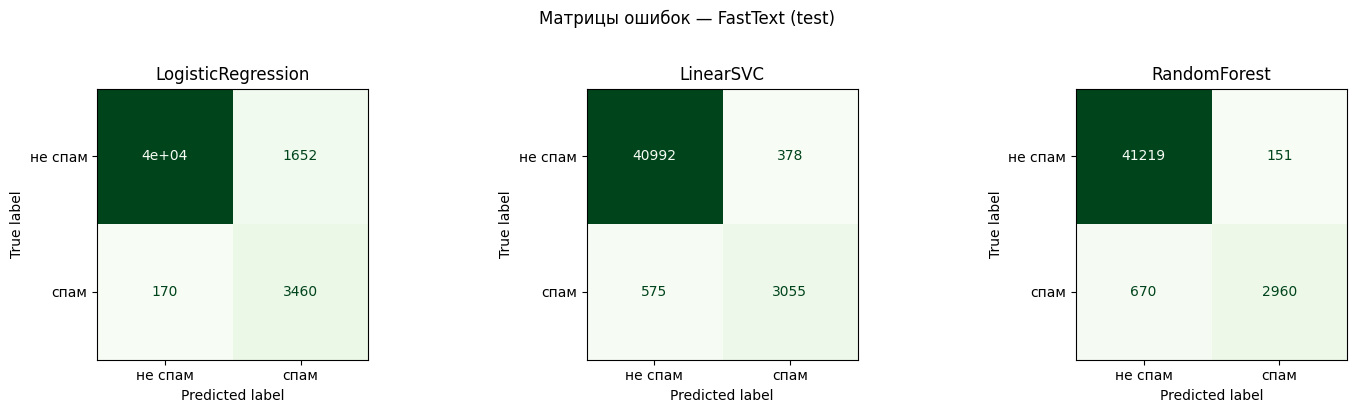

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, clf_path) in zip(axes, [
    ("LogisticRegression", "logisticregression.pkl"),
    ("LinearSVC", "linearsvc.pkl"),
    ("RandomForest", "randomforest.pkl"),
]):
    with open(os.path.join(MODELS_DIR, clf_path), "rb") as f:
        clf = pickle.load(f)
    y_pred = clf.predict(X_test_ft)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["не спам", "спам"]).plot(
        ax=ax, colorbar=False, cmap="Greens")
    ax.set_title(name)

plt.suptitle("Матрицы ошибок — FastText (test)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fasttext_confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()